In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import pickle
import gc
import warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU: {gpus[0]}")

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

core_path    = os.getcwd()
tuner_path   = os.path.join(core_path, 'tuner_logs')
os.makedirs(tuner_path,   exist_ok=True)

# Install keras-tuner if needed
# !pip install keras-tuner

I0000 00:00:1779593936.173867   56203 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779593936.212583   56203 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779593937.565018   56203 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
core_path    = os.getcwd()
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))
family_df = orbital_df[orbital_df['is_family_member']].copy().reset_index(drop=True)

FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']

le = LabelEncoder()
y  = le.fit_transform(family_df['family_1'].values)
n_classes = len(le.classes_)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=y
)
class_weight_dict = dict(enumerate(class_weights_arr))

X = family_df[FEATURES_A].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")
print(f"Classes : {n_classes}")

Train : 166,036 | Val : 18,449 | Test : 46,122
Classes : 98


In [3]:
def build_hypermodel(hp):
    # Search space
    n_layers = hp.Int('n_layers', min_value=2, max_value=6, step=1)
    units_first = hp.Choice('units_first', [128, 256, 512, 1024])
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4])
    l2_reg = hp.Choice('l2_reg', [1e-3, 1e-4, 1e-5])
    use_batchnorm = hp.Boolean('use_batchnorm')

    inputs = keras.Input(shape=(len(FEATURES_A),))
    x      = inputs

    # First layer
    x = layers.Dense(
        units_first, activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(l2_reg)
    )(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Subsequent layers — halve units each time
    for i in range(1, n_layers):
        units = max(32, units_first // (2 ** i))
        x = layers.Dense(
            units, activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=keras.regularizers.l2(l2_reg)
        )(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    return model

In [4]:
tuner = kt.BayesianOptimization(
    hypermodel=build_hypermodel,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_trials=30,           # number of hyperparameter combinations to try
    num_initial_points=5,    # random trials before Bayesian kicks in
    directory=tuner_path,
    project_name='05b_iii_multiclass',
    overwrite=True
)

tuner.search_space_summary()

I0000 00:00:1779593946.181502   56203 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2864 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Search space summary
Default search space size: 6
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 6, 'step': 1, 'sampling': 'linear'}
units_first (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512, 1024], 'ordered': True}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}
l2_reg (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05], 'ordered': True}
use_batchnorm (Boolean)
{'default': False, 'conditions': []}


In [5]:
search_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        mode='min'
    )
]

print("Starting Bayesian search — 30 trials...")
print("Each trial runs up to 20 epochs with early stopping\n")

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,              # max epochs per trial — early stopping cuts short
    batch_size=2048,
    class_weight=class_weight_dict,
    callbacks=search_callbacks,
    verbose=1
)

print("\nSearch complete.")
tuner.results_summary()

Trial 30 Complete [00h 00m 33s]
val_accuracy: 0.9147921204566956

Best val_accuracy So Far: 0.9809203743934631
Total elapsed time: 00h 19m 36s

Search complete.
Results summary
Results in /media/shade/DA86EB1886EAF443/Projects/Asteroid_OrbitalDynamics (Proper-Element)/tuner_logs/05b_iii_multiclass
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 26 summary
Hyperparameters:
n_layers: 4
units_first: 1024
dropout_rate: 0.1
learning_rate: 0.001
l2_reg: 0.0001
use_batchnorm: True
Score: 0.9809203743934631

Trial 13 summary
Hyperparameters:
n_layers: 2
units_first: 512
dropout_rate: 0.1
learning_rate: 0.01
l2_reg: 1e-05
use_batchnorm: True
Score: 0.9805951714515686

Trial 17 summary
Hyperparameters:
n_layers: 4
units_first: 1024
dropout_rate: 0.1
learning_rate: 0.0005
l2_reg: 1e-05
use_batchnorm: True
Score: 0.9800531268119812

Trial 10 summary
Hyperparameters:
n_layers: 2
units_first: 1024
dropout_rate: 0.1
learning_rate: 0.0005
l2_reg: 0.0001
use_batchnorm: Tru

In [6]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=== Best Hyperparameters ===")
print(f"n_layers      : {best_hps.get('n_layers')}")
print(f"units_first   : {best_hps.get('units_first')}")
print(f"dropout_rate  : {best_hps.get('dropout_rate')}")
print(f"learning_rate : {best_hps.get('learning_rate')}")
print(f"l2_reg        : {best_hps.get('l2_reg')}")
print(f"use_batchnorm : {best_hps.get('use_batchnorm')}")

=== Best Hyperparameters ===
n_layers      : 4
units_first   : 1024
dropout_rate  : 0.1
learning_rate : 0.001
l2_reg        : 0.0001
use_batchnorm : True


In [11]:
best_model = tuner.hypermodel.build(best_hps)

final_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, mode='min'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, mode='min', verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=os.path.join('data', 'results', 'classification_results', '07a_iii_best_model.keras'),
        monitor='val_loss', save_best_only=True,
        mode='min', verbose=0
    )
]

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=2048,
    class_weight=class_weight_dict,
    callbacks=final_callbacks,
    verbose=1
)

Epoch 1/80


I0000 00:00:1779595519.077312   56271 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_878938__.53


81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3914 - loss: 3.0858 - top3_acc: 0.5874

I0000 00:00:1779595524.686777   56270 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_878938__.53


82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.5822 - loss: 2.2058 - top3_acc: 0.7914 - val_accuracy: 0.5234 - val_loss: 2.2701 - val_top3_acc: 0.8016 - learning_rate: 0.0010
Epoch 2/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8279 - loss: 1.0972 - top3_acc: 0.9712 - val_accuracy: 0.8166 - val_loss: 1.1247 - val_top3_acc: 0.9450 - learning_rate: 0.0010
Epoch 3/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8743 - loss: 0.9107 - top3_acc: 0.9808 - val_accuracy: 0.8950 - val_loss: 0.7514 - val_top3_acc: 0.9930 - learning_rate: 0.0010
Epoch 4/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8962 - loss: 0.8026 - top3_acc: 0.9854 - val_accuracy: 0.8941 - val_loss: 0.7106 - val_top3_acc: 0.9876 - learning_rate: 0.0010
Epoch 5/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9124 - loss: 0.6815 - top3_acc: 0.9911 - val_accuracy: 0.9314 - val_loss: 0.5775 - val_top3_acc: 0.9970 - learning_rate: 0.0010
Epoch 6/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

In [12]:
y_pred_proba = best_model.predict(X_test, batch_size=2048)
y_pred       = np.argmax(y_pred_proba, axis=1)

acc          = accuracy_score(y_test, y_pred)
f1_macro     = f1_score(y_test, y_pred, average='macro')
f1_weighted  = f1_score(y_test, y_pred, average='weighted')
per_class_f1 = f1_score(y_test, y_pred, average=None)

print(f"=== DL Keras Tuner — Set A Orbital ===")
print(f"Accuracy        : {acc:.4f}")
print(f"F1 Macro        : {f1_macro:.4f}")
print(f"F1 Weighted     : {f1_weighted:.4f}")
print(f"Min per-class F1: {per_class_f1.min():.4f} "
      f"(family {le.classes_[per_class_f1.argmin()]})")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
=== DL Keras Tuner — Set A Orbital ===
Accuracy        : 0.9894
F1 Macro        : 0.9467
F1 Weighted     : 0.9918
Min per-class F1: 0.0000 (family 2)


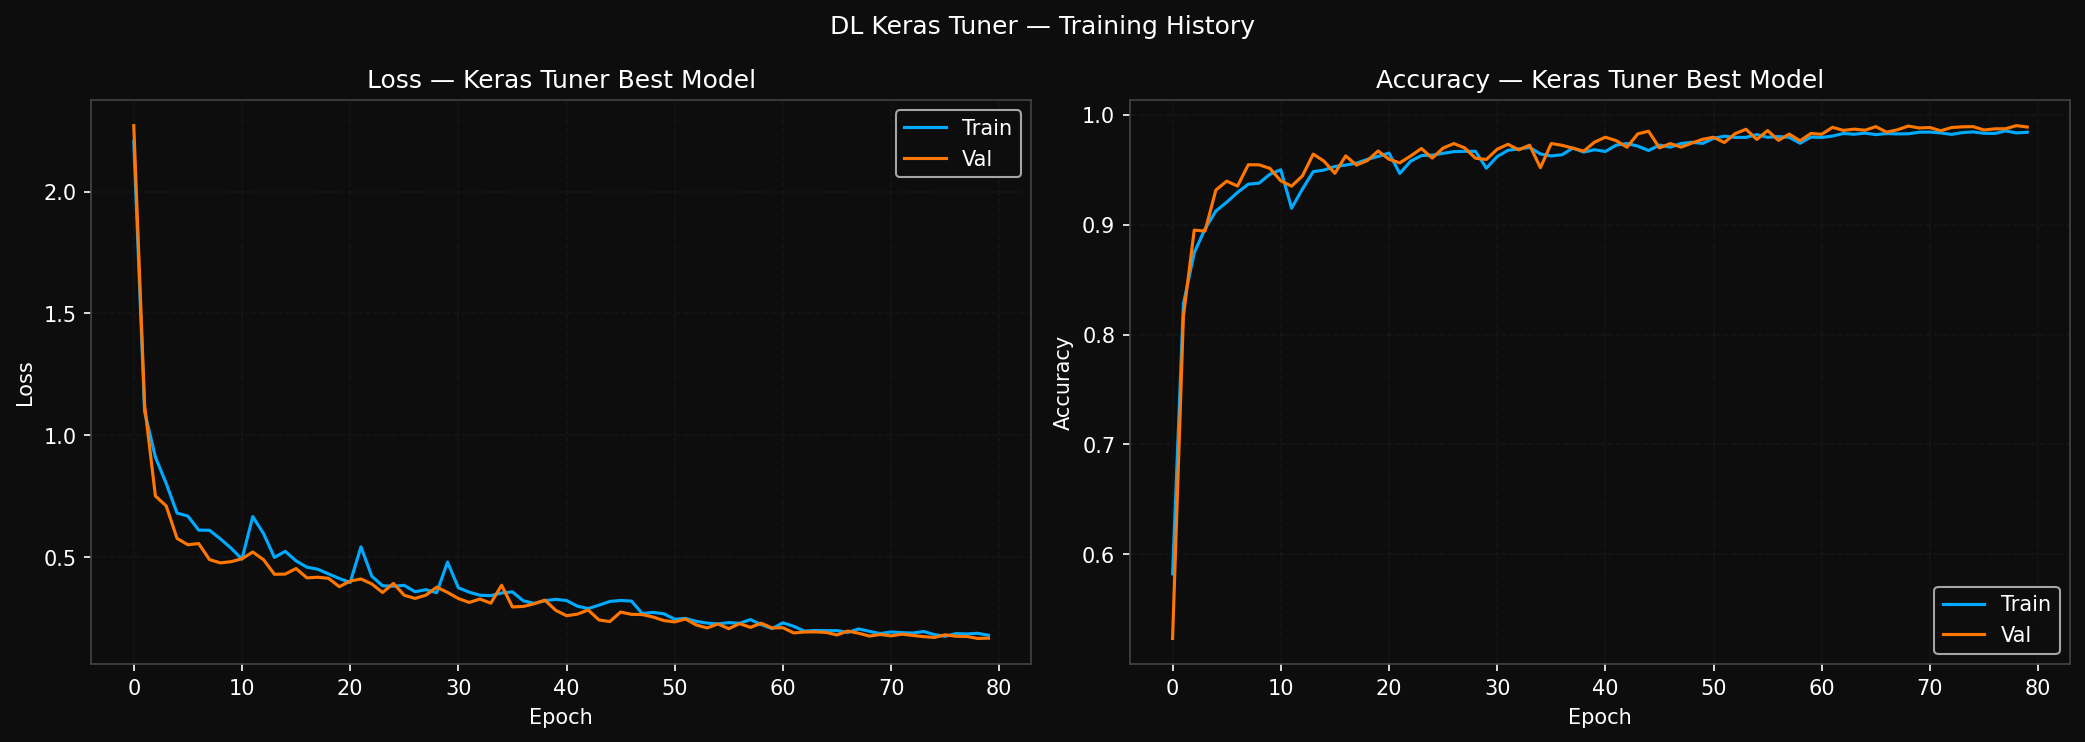

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist = history.history

axes[0].plot(hist['loss'],     label='Train', color='#00aaff')
axes[0].plot(hist['val_loss'], label='Val',   color='#ff7700')
axes[0].set_title('Loss — Keras Tuner Best Model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist['accuracy'],     label='Train', color='#00aaff')
axes[1].plot(hist['val_accuracy'], label='Val',   color='#ff7700')
axes[1].set_title('Accuracy — Keras Tuner Best Model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('DL Keras Tuner — Training History', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_iii_tuner_history.png'), dpi=200, bbox_inches='tight')
plt.show()

In [14]:
with open(os.path.join('data', 'results', 'classification_results', '07a_i_multiclass_rf_results.pkl'), 'rb') as f:
    rf_results = pickle.load(f)
with open(os.path.join('data', 'results', 'classification_results', '07a_ii_dl_multiclass_results.pkl'), 'rb') as f:
    dl_base_results = pickle.load(f)

print(f"\n{'='*70}")
print(f"{'Multiclass — Complete Summary':^70}")
print(f"{'='*70}")
print(f"{'Model':<35} {'Acc':>8} {'F1 Macro':>10} {'F1 Weighted':>12}")
print(f"{'-'*70}")

for feat_name, res in rf_results.items():
    print(f"{'RF_'+feat_name:<35} {res['acc']:>8.4f} "
          f"{res['f1_macro']:>10.4f} {res['f1_weighted']:>12.4f}")

for feat_name, res in dl_base_results.items():
    print(f"{'DL_Dense_'+feat_name:<35} {res['acc']:>8.4f} "
          f"{res['f1_macro']:>10.4f} {res['f1_weighted']:>12.4f}")

print(f"{'DL_Tuned_Set_A_orbital':<35} {acc:>8.4f} "
      f"{f1_macro:>10.4f} {f1_weighted:>12.4f}")


                    Multiclass — Complete Summary                     
Model                                    Acc   F1 Macro  F1 Weighted
----------------------------------------------------------------------
RF_Set_A_orbital                      0.9992     0.9919       0.9992
RF_Set_B_full                         0.9992     0.9941       0.9992
DL_Dense_Set_A_orbital                0.9564     0.9183       0.9675
DL_Dense_Set_B_full                   0.9010     0.8010       0.9227
DL_Tuned_Set_A_orbital                0.9894     0.9467       0.9918


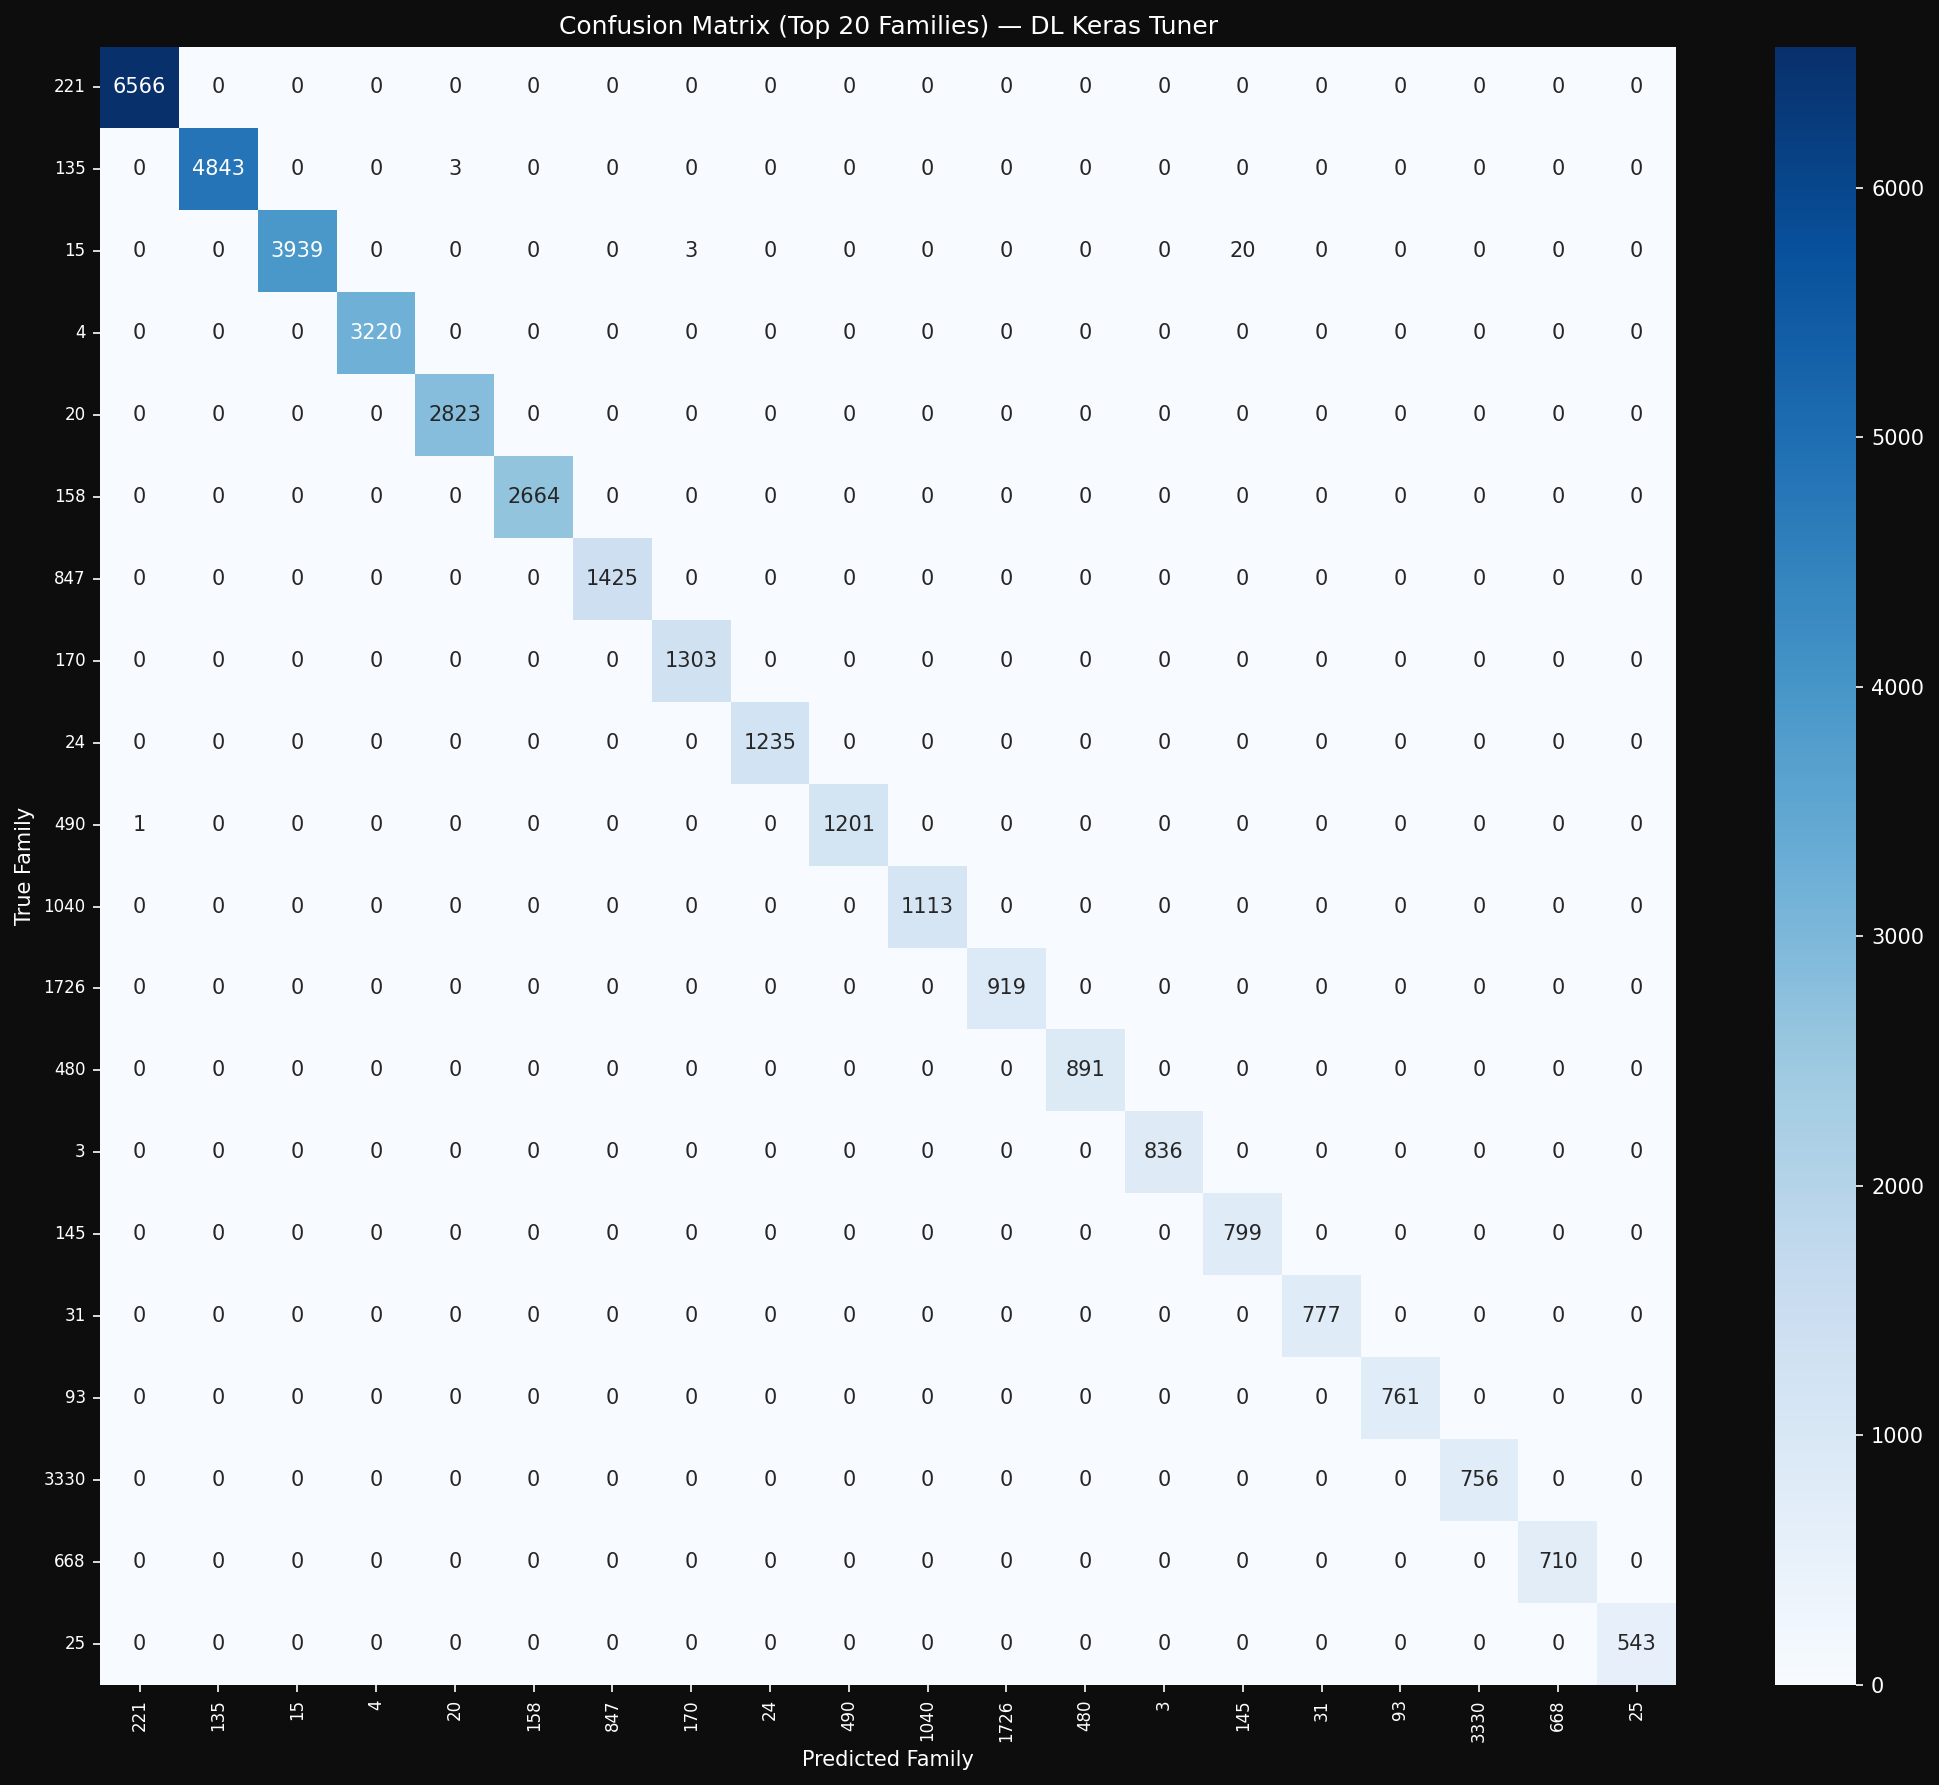

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

top20_families = (
    family_df.groupby('family_1').size()
    .sort_values(ascending=False)
    .head(20).index.tolist()
)
top20_encoded = le.transform(top20_families)

fig, ax = plt.subplots(figsize=(14, 12))

# Filter test set to top 20 families
mask  = np.isin(y_test, top20_encoded)
y_t   = y_test[mask]
y_p   = y_pred[mask]

# Remap to 0..19 for display
remap  = {v: i for i, v in enumerate(top20_encoded)}
y_t_r  = np.array([remap[v] for v in y_t])
y_p_r  = np.array([remap.get(v, -1) for v in y_p])

cm = confusion_matrix(y_t_r, y_p_r, labels=list(range(len(top20_families))))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=top20_families,
    yticklabels=top20_families,
    ax=ax
)
ax.set_xlabel('Predicted Family')
ax.set_ylabel('True Family')
ax.set_title('Confusion Matrix (Top 20 Families) — DL Keras Tuner')
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_iii_tuner_confusion_top20.png'),
            # dpi=200, bbox_inches='tight')
plt.show()

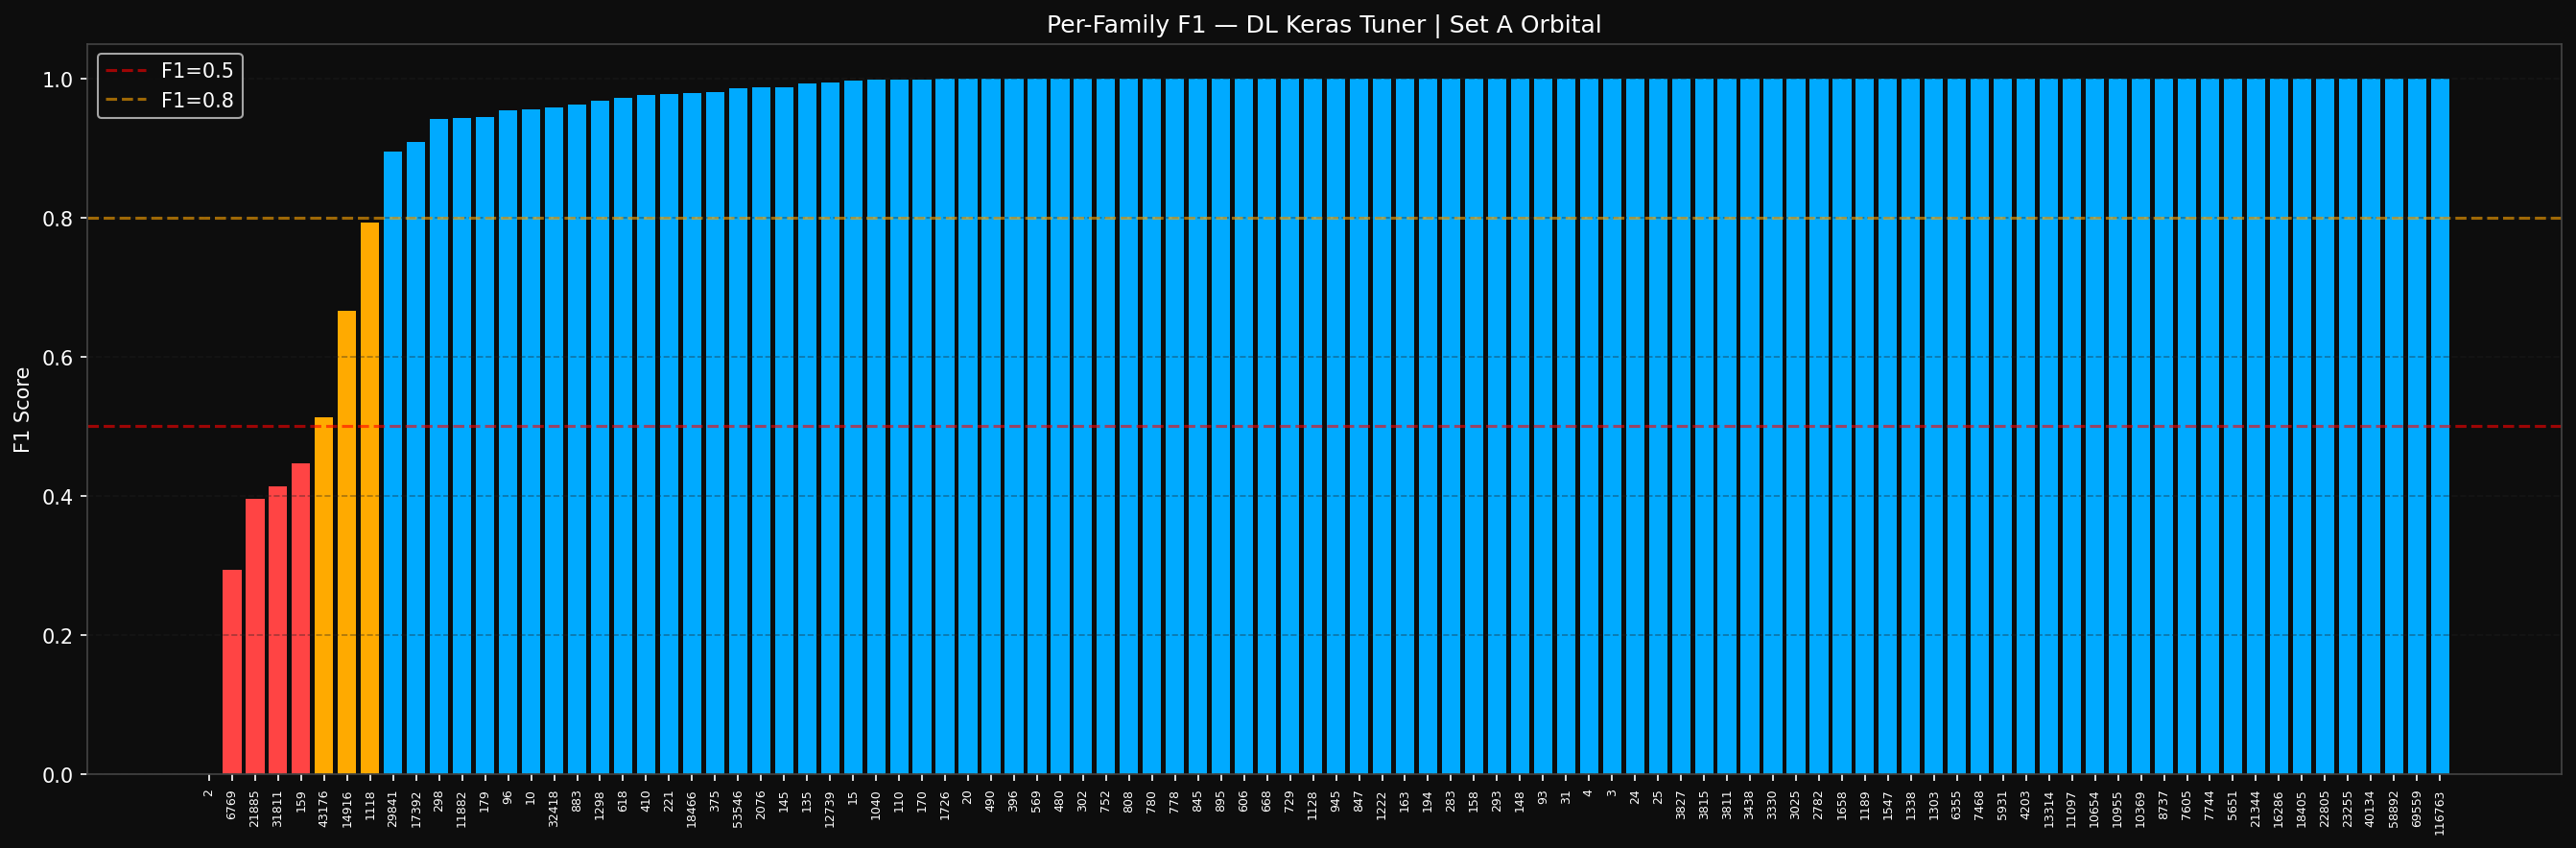

In [19]:
fig, ax = plt.subplots(figsize=(18, 6))

sorted_idx   = np.argsort(per_class_f1)
family_names = [str(le.classes_[i]) for i in sorted_idx]

colors = ['#ff4444' if f < 0.5 else '#ffaa00' if f < 0.8 else '#00aaff'
          for f in per_class_f1[sorted_idx]]

ax.bar(range(len(per_class_f1)), per_class_f1[sorted_idx],
       color=colors, edgecolor='none')
ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, label='F1=0.5')
ax.axhline(0.8, color='orange', linestyle='--', alpha=0.6, label='F1=0.8')
ax.set_xticks(range(len(per_class_f1)))
ax.set_xticklabels(family_names, rotation=90, fontsize=6)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Family F1 — DL Keras Tuner | Set A Orbital')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_iii_tuner_perclass_f1.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

In [15]:
tuner_save = {
    'best_hps': {
        'n_layers':      best_hps.get('n_layers'),
        'units_first':   best_hps.get('units_first'),
        'dropout_rate':  best_hps.get('dropout_rate'),
        'learning_rate': best_hps.get('learning_rate'),
        'l2_reg':        best_hps.get('l2_reg'),
        'use_batchnorm': best_hps.get('use_batchnorm'),
    },
    'history':      history.history,
    'y_test':       y_test,
    'y_pred':       y_pred,
    'acc':          acc,
    'f1_macro':     f1_macro,
    'f1_weighted':  f1_weighted,
    'per_class_f1': per_class_f1,
}

with open(os.path.join('data', 'results', 'classification_results', '07a_iii_tuner_results.pkl'), 'wb') as f:
    pickle.dump(tuner_save, f)

print("Saved → data/results/classification_results/07a_iii_tuner_results.pkl")

Saved → data/results/classification_results/07a_iii_tuner_results.pkl
